# Agente inteligente para predicción y evaluación de modelos de regresión

Este notebook implementa un agente inteligente en Python que coordina todo el proceso:

1. Carga del dataset.
2. Limpieza básica.
3. Detección de variables numéricas y categóricas.
4. División en entrenamiento y prueba.
5. Preprocesamiento automático.
6. Entrenamiento de varios modelos de regresión.
7. Evaluación mediante RMSE, MAE y R².
8. Selección automática del mejor modelo.
9. Predicción final sobre nuevos datos.

> Cambie únicamente la ruta del archivo y el nombre de la variable objetivo.


In [31]:
# ===============================
# CELDA 1: Instalación opcional
# ===============================
# Si alguna librería no está instalada, quite el comentario y ejecute:
# !pip install pandas numpy scikit-learn matplotlib joblib


In [32]:
# ===============================
# CELDA 2: Importación de librerías
# ===============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

import matplotlib.pyplot as plt
import joblib

RANDOM_STATE = 42


In [33]:
# ===============================
# CELDA 3: Clase del agente inteligente
# ===============================

class IntelligentRegressionAgent:
    def __init__(self, target_column=None, test_size=0.25, random_state=42):
        self.target_column = target_column
        self.test_size = test_size
        self.random_state = random_state

        self.data = None
        self.X = None
        self.y = None

        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

        self.numeric_features = None
        self.categorical_features = None
        self.preprocessor = None

        self.models = {}
        self.results = None
        self.best_model_name = None
        self.best_model = None

    def load_dataset(self, path):
        print("1. Cargando dataset...")

        if path.endswith(".csv"):
            self.data = pd.read_csv(path)
        elif path.endswith((".xlsx", ".xls")):
            self.data = pd.read_excel(path)
        else:
            raise ValueError("Formato no soportado. Use un archivo .csv, .xlsx o .xls")

        print(f"Dataset cargado con {self.data.shape[0]} filas y {self.data.shape[1]} columnas.")
        return self.data.head()

    def inspect_dataset(self):
        print("2. Información general del dataset:")
        display(self.data.head())
        print("\nColumnas disponibles:")
        print(list(self.data.columns))
        print("\nDimensiones:", self.data.shape)
        print("\nValores nulos por columna:")
        display(self.data.isnull().sum())
        print("\nTipos de datos:")
        display(self.data.dtypes)

    def resolve_target_column(self, df):
        """
        Resuelve la variable objetivo.
        - Si TARGET_COLUMN existe, la usa.
        - Si TARGET_COLUMN es None o no existe, selecciona automáticamente la última columna numérica.
        """
        if self.target_column in df.columns:
            return self.target_column

        numeric_columns = df.select_dtypes(include=["number"]).columns.tolist()

        if len(numeric_columns) == 0:
            raise ValueError(
                "No se encontró una columna objetivo válida. "
                "El dataset no contiene columnas numéricas para usar como variable objetivo de regresión."
            )

        selected_column = numeric_columns[-1]

        if self.target_column is None:
            print(
                f"TARGET_COLUMN no fue definido. "
                f"Se usará automáticamente la última columna numérica: '{selected_column}'."
            )
        else:
            print(
                f"La columna objetivo '{self.target_column}' no existe en el dataset. "
                f"Se usará automáticamente la última columna numérica: '{selected_column}'."
            )

        print("Columnas numéricas disponibles:", numeric_columns)
        self.target_column = selected_column
        return selected_column

    def prepare_features_target(self):
        print("3. Separando variables predictoras y variable objetivo...")

        df = self.data.copy()
        df = df.drop_duplicates()

        target_column = self.resolve_target_column(df)

        # Convierte la variable objetivo a numérica cuando sea posible.
        df[target_column] = pd.to_numeric(df[target_column], errors="coerce")
        df = df.dropna(subset=[target_column])

        if df.empty:
            raise ValueError(
                f"La columna objetivo '{target_column}' no contiene valores numéricos válidos."
            )

        self.X = df.drop(columns=[target_column])
        self.y = df[target_column]

        self.numeric_features = self.X.select_dtypes(
            include=["int64", "float64", "int32", "float32", "number"]
        ).columns.tolist()

        self.categorical_features = self.X.select_dtypes(
            include=["object", "category", "bool"]
        ).columns.tolist()

        if len(self.numeric_features) == 0 and len(self.categorical_features) == 0:
            raise ValueError("No hay variables predictoras válidas después de separar la variable objetivo.")

        print("Variable objetivo usada:", self.target_column)
        print("Variables numéricas:", self.numeric_features)
        print("Variables categóricas:", self.categorical_features)

    def split_data(self):
        print("4. Dividiendo datos en entrenamiento y prueba...")
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X,
            self.y,
            test_size=self.test_size,
            random_state=self.random_state
        )
        print("Entrenamiento:", self.X_train.shape)
        print("Prueba:", self.X_test.shape)

    def build_preprocessor(self):
        print("5. Construyendo preprocesamiento automático...")

        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])

        transformers = []

        if len(self.numeric_features) > 0:
            transformers.append(("num", numeric_transformer, self.numeric_features))

        if len(self.categorical_features) > 0:
            transformers.append(("cat", categorical_transformer, self.categorical_features))

        self.preprocessor = ColumnTransformer(transformers=transformers)

        print("Preprocesamiento creado correctamente.")

    def define_models(self):
        print("6. Definiendo modelos candidatos...")

        self.models = {
            "Regresión Lineal": LinearRegression(),
            "Ridge": Ridge(random_state=self.random_state),
            "Lasso": Lasso(random_state=self.random_state),
            "ElasticNet": ElasticNet(random_state=self.random_state),
            "Árbol de Decisión": DecisionTreeRegressor(random_state=self.random_state),
            "Random Forest": RandomForestRegressor(n_estimators=200, random_state=self.random_state),
            "Extra Trees": ExtraTreesRegressor(n_estimators=200, random_state=self.random_state),
            "Gradient Boosting": GradientBoostingRegressor(random_state=self.random_state),
            "KNN": KNeighborsRegressor(n_neighbors=5),
            "SVR RBF": SVR(kernel="rbf")
        }

        print(f"{len(self.models)} modelos definidos.")

    def train_and_evaluate(self):
        print("7. Entrenando y evaluando modelos de regresión...")

        results = []

        for name, model in self.models.items():
            print(f"Entrenando: {name}")

            pipeline = Pipeline(steps=[
                ("preprocessor", self.preprocessor),
                ("model", model)
            ])

            try:
                pipeline.fit(self.X_train, self.y_train)

                y_pred = pipeline.predict(self.X_test)

                mae = mean_absolute_error(self.y_test, y_pred)
                rmse = np.sqrt(mean_squared_error(self.y_test, y_pred))
                r2 = r2_score(self.y_test, y_pred)

                results.append({
                    "Modelo": name,
                    "MAE": mae,
                    "RMSE": rmse,
                    "R2": r2,
                    "Pipeline": pipeline
                })

            except Exception as e:
                print(f"Error con el modelo {name}: {e}")

        if len(results) == 0:
            raise RuntimeError(
                "Ningún modelo pudo entrenarse. Revise el dataset, la variable objetivo y las columnas predictoras."
            )

        self.results = pd.DataFrame(results).sort_values(by="RMSE", ascending=True).reset_index(drop=True)

        self.best_model_name = self.results.loc[0, "Modelo"]
        self.best_model = self.results.loc[0, "Pipeline"]

        print("\nMejor modelo:", self.best_model_name)
        print("Mejor RMSE:", round(self.results.loc[0, "RMSE"], 4))
        print("R2 del mejor modelo:", round(self.results.loc[0, "R2"], 4))

        return self.results[["Modelo", "MAE", "RMSE", "R2"]]

    def validate_trained_agent(self):
        if self.best_model is None or self.results is None or self.X_test is None:
            raise RuntimeError(
                "El agente todavía no tiene un modelo entrenado. "
                "Ejecute primero la CELDA 5 correctamente."
            )

    def show_rmse_chart(self):
        self.validate_trained_agent()
        print("8. Gráfico comparativo de RMSE...")

        chart_data = self.results[["Modelo", "RMSE"]].copy()
        chart_data = chart_data.sort_values("RMSE", ascending=True)

        plt.figure(figsize=(10, 6))
        plt.barh(chart_data["Modelo"], chart_data["RMSE"])
        plt.xlabel("RMSE")
        plt.ylabel("Modelo")
        plt.title("Comparación de modelos según RMSE")
        plt.show()

    def final_report(self):
        self.validate_trained_agent()
        print("9. Reporte final del mejor modelo")

        y_pred = self.best_model.predict(self.X_test)

        mae = mean_absolute_error(self.y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(self.y_test, y_pred))
        r2 = r2_score(self.y_test, y_pred)

        print("Modelo seleccionado:", self.best_model_name)
        print("MAE:", round(mae, 4))
        print("RMSE:", round(rmse, 4))
        print("R2:", round(r2, 4))

        comparison = pd.DataFrame({
            "Valor_real": self.y_test.values,
            "Valor_predicho": y_pred,
            "Error": self.y_test.values - y_pred
        })

        print("\nPrimeras predicciones:")
        display(comparison.head(10))

        plt.figure(figsize=(7, 6))
        plt.scatter(self.y_test, y_pred, alpha=0.7)
        plt.xlabel("Valores reales")
        plt.ylabel("Valores predichos")
        plt.title(f"Valores reales vs predichos - {self.best_model_name}")
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.hist(comparison["Error"], bins=20)
        plt.xlabel("Error")
        plt.ylabel("Frecuencia")
        plt.title("Distribución de errores del mejor modelo")
        plt.show()

    def predict_new_data(self, new_data):
        self.validate_trained_agent()
        print("10. Realizando predicción sobre nuevos datos...")

        if isinstance(new_data, dict):
            new_data = pd.DataFrame([new_data])

        prediction = self.best_model.predict(new_data)

        result = pd.DataFrame({
            "Predicción": prediction
        })

        return result

    def save_best_model(self, filename="best_regression_model.pkl"):
        self.validate_trained_agent()
        joblib.dump(self.best_model, filename)
        print(f"Modelo guardado como: {filename}")

    def run_all(self, path):
        self.load_dataset(path)
        self.inspect_dataset()
        self.prepare_features_target()
        self.split_data()
        self.build_preprocessor()
        self.define_models()
        display(self.train_and_evaluate())
        self.show_rmse_chart()
        self.final_report()


In [34]:
# ===============================
# CELDA 4: Configuración del dataset
# ===============================
# Cambie esta ruta por la ruta real de su archivo CSV o Excel.
# Ejemplo:
# DATASET_PATH = "/Users/juan/Desktop/housing.csv"

DATASET_PATH = "/home/dnunezf/Documents/AI_LABS/Lab_21-05-2026/potabilidad_V2.csv"

# Coloque aquí la columna objetivo numérica real.
# Ejemplos: "price", "salary", "charges", "medv", etc.
# Si lo deja en None, el agente usará automáticamente la última columna numérica del dataset.

TARGET_COLUMN = None


1. Cargando dataset...
Dataset cargado con 2011 filas y 11 columnas.
2. Información general del dataset:


,Unnamed: 0,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,4,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,No
1,5,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,No
2,6,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,No
3,7,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,No
4,8,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,No



Columnas disponibles:
['Unnamed: 0', 'ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']

Dimensiones: (2011, 11)

Valores nulos por columna:


Unnamed: 0         0
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


Tipos de datos:


Unnamed: 0           int64
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability          object
dtype: object

3. Separando variables predictoras y variable objetivo...
TARGET_COLUMN no fue definido. Se usará automáticamente la última columna numérica: 'Turbidity'.
Columnas numéricas disponibles: ['Unnamed: 0', 'ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']
Variable objetivo usada: Turbidity
Variables numéricas: ['Unnamed: 0', 'ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes']
Variables categóricas: ['Potability']
4. Dividiendo datos en entrenamiento y prueba...
Entrenamiento: (1508, 10)
Prueba: (503, 10)
5. Construyendo preprocesamiento automático...
Preprocesamiento creado correctamente.
6. Definiendo modelos candidatos...
10 modelos definidos.
7. Entrenando y evaluando modelos de regresión...
Entrenando: Regresión Lineal
Entrenando: Ridge
Entrenando: Lasso
Entrenando: ElasticNet
Entrenando: Árbol de Decisión
Entrenando: Random Forest
Entrenando: Extra Trees
Entrena

,Modelo,MAE,RMSE,R2
0,ElasticNet,0.618648,0.782872,-0.000339
1,Lasso,0.618648,0.782872,-0.000339
2,Ridge,0.619308,0.784738,-0.005112
3,Regresión Lineal,0.619311,0.784742,-0.005123
4,Random Forest,0.623033,0.792297,-0.024568
5,Extra Trees,0.624514,0.795167,-0.032005
6,Gradient Boosting,0.630868,0.797283,-0.037506
7,SVR RBF,0.642687,0.820369,-0.098458
8,KNN,0.650097,0.833031,-0.132629
9,Árbol de Decisión,0.897017,1.128026,-1.076841


8. Gráfico comparativo de RMSE...


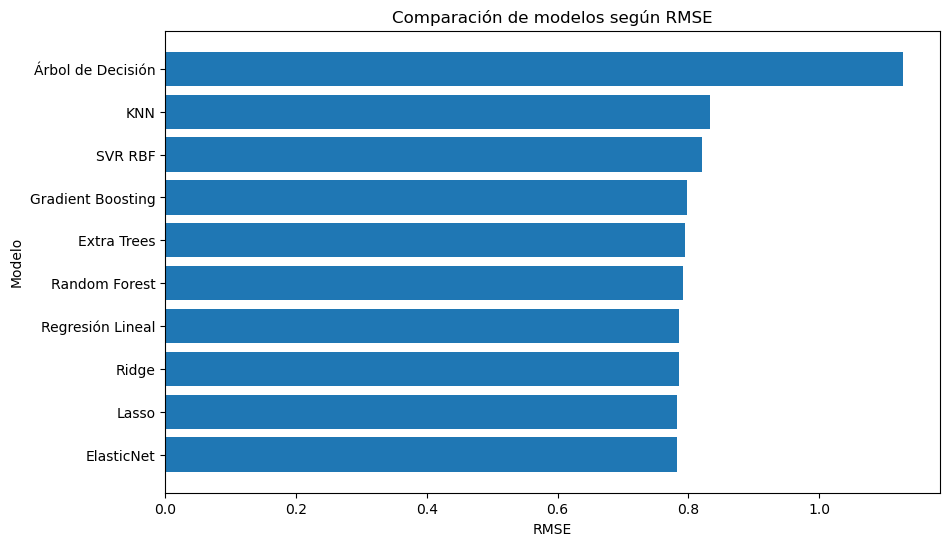

9. Reporte final del mejor modelo
Modelo seleccionado: ElasticNet
MAE: 0.6186
RMSE: 0.7829
R2: -0.0003

Primeras predicciones:


,Valor_real,Valor_predicho,Error
0,4.469431,3.973332,0.496099
1,5.400811,3.973332,1.427479
2,3.771314,3.973332,-0.202018
3,4.581477,3.973332,0.608146
4,4.633855,3.973332,0.660523
5,3.808372,3.973332,-0.164960
6,4.147169,3.973332,0.173837
7,3.238693,3.973332,-0.734639
8,2.978925,3.973332,-0.994406
9,4.179187,3.973332,0.205855


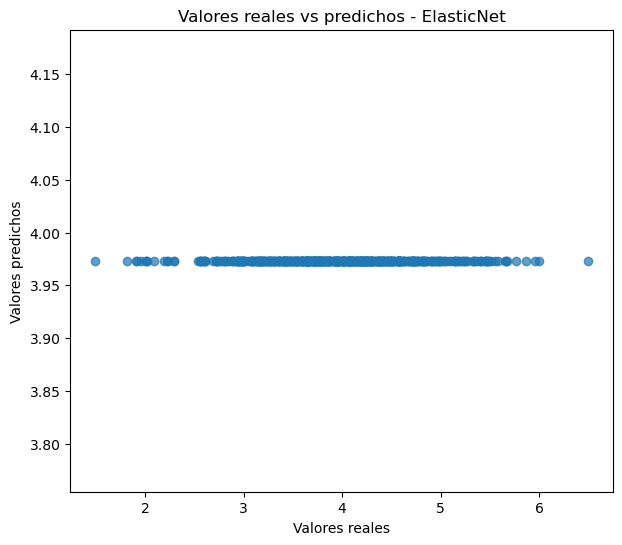

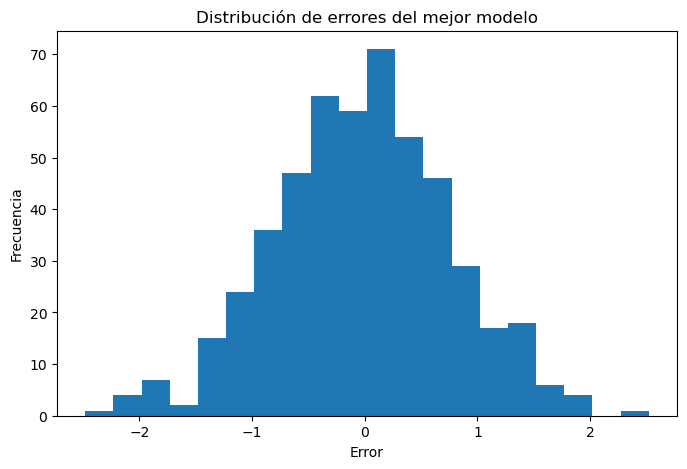

In [35]:
# ===============================
# CELDA 5: Crear y ejecutar el agente completo
# ===============================

agent = IntelligentRegressionAgent(
    target_column=TARGET_COLUMN,
    test_size=0.25,
    random_state=42
)

agent.run_all(DATASET_PATH)


In [36]:
# ===============================
# CELDA 6: Ver tabla final de resultados
# ===============================

agent.validate_trained_agent()
agent.results[["Modelo", "MAE", "RMSE", "R2"]]


,Modelo,MAE,RMSE,R2
0,ElasticNet,0.618648,0.782872,-0.000339
1,Lasso,0.618648,0.782872,-0.000339
2,Ridge,0.619308,0.784738,-0.005112
3,Regresión Lineal,0.619311,0.784742,-0.005123
4,Random Forest,0.623033,0.792297,-0.024568
5,Extra Trees,0.624514,0.795167,-0.032005
6,Gradient Boosting,0.630868,0.797283,-0.037506
7,SVR RBF,0.642687,0.820369,-0.098458
8,KNN,0.650097,0.833031,-0.132629
9,Árbol de Decisión,0.897017,1.128026,-1.076841


In [37]:
# ===============================
# CELDA 7: Predicción con un nuevo registro
# ===============================
# Importante:
# El nuevo registro debe tener las mismas columnas predictoras del dataset original,
# excepto la variable objetivo.

agent.validate_trained_agent()

nuevo_registro = agent.X_test.iloc[0].to_dict()

prediccion = agent.predict_new_data(nuevo_registro)
prediccion


10. Realizando predicción sobre nuevos datos...


,Predicción
0,3.973332


In [38]:
# ===============================
# CELDA 8: Guardar el mejor modelo
# ===============================

agent.save_best_model("mejor_modelo_regresion.pkl")


Modelo guardado como: mejor_modelo_regresion.pkl


In [39]:
# ===============================
# CELDA 9: Cargar el modelo guardado
# ===============================

agent.validate_trained_agent()

modelo_cargado = joblib.load("mejor_modelo_regresion.pkl")

# Ejemplo de predicción con el modelo cargado
modelo_cargado.predict(agent.X_test.iloc[[0]])


array([3.97333169])

## Interpretación básica de métricas de regresión

- **MAE**: error absoluto medio. Indica cuánto se equivoca el modelo en promedio.
- **RMSE**: raíz del error cuadrático medio. Penaliza más los errores grandes.
- **R²**: proporción de varianza explicada por el modelo.

Criterio usado por el agente:

- El mejor modelo será el que obtenga el **RMSE más bajo** en el conjunto de prueba.
- Un **R² cercano a 1** indica mejor ajuste.
- Un **R² cercano a 0** indica que el modelo explica poco la variabilidad de la variable objetivo.
- Un **R² negativo** indica que el modelo puede estar rindiendo peor que una predicción basada en el promedio.
